# LABORATORIO 2021-22

## Sesión 2:  Uso de SageMath como calculadora avanzada.

_____



### **Ejercicio 1** ### 

Se considera la funcion $f(x)=\dfrac{x^2+1}{|x-4|}$.

**a)** Determinar sus asíntotas oblicuas con la ayuda de SageMath. 

**b)** Dibujar la función  junto con sus asíntotas (vertical y oblicuas) en el intervalo $[-40,40]$.

*Sugerencia:* Para dibujar la asíntota vertical puede ser útil la instrucción $\texttt{line}$.

**c)** Calcula los puntos del dominio de la función donde se anula su derivada.

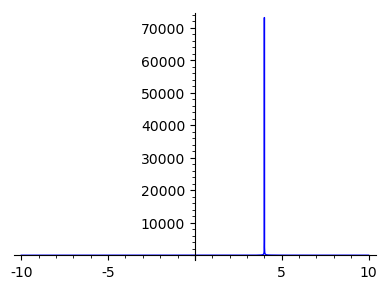

In [1]:
f(x)=(x^2+1)/abs(x-4) # Empezamos definiendo la función
plot(f,-10,10,figsize=4) # Primera tentativa de representacion

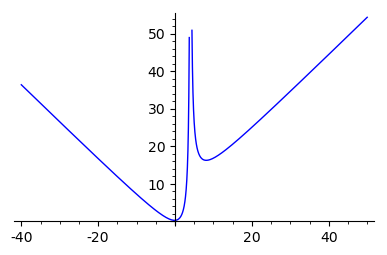

In [2]:
# Como vemos, el gran tamaño de la función cerca de la asíntota vertical  $x=4$...
#...hace que no se aprecie la función lejos de esta. 
# Así que en el dibujo intentamos alejarnos un poco de la asíntota.
dibujo=plot(f,-40,3.7,figsize=4)+plot(f,4.4,50) # Gráficas concatenadas (figsize solo en una)
show(dibujo)

> En esta segunda visualización de la gráfica, vemos comportamientos asintóticos. De nuestros conocimientos de Cálculo, sabemos qué limites hay que calcular para determinar las rectas asíntotas oblicuas.

In [3]:
#Obsérvese el orden de las asignaciones: n1 necesita conocer m1 (lo mismo para n2 y m2)
#a)
m1=limit(f(x)/x,x=oo) #pendiente de la asíntota en +infty
n1=limit(f(x)-m1*x,x=oo) #ordenada en el origen de la asíntota en +infty
m2=limit(f(x)/x,x=-oo) #pendiente de la asíntota en -infty
n2=limit(f(x)-m2*x,x=-oo) #ordenada en el origen de la asíntota en -infty

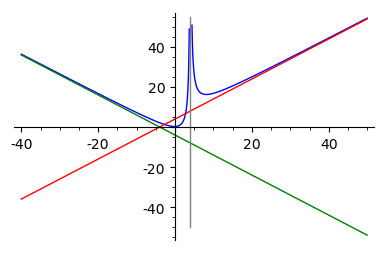

In [4]:
#b)
# Añadimos en primer lugar las asíntotas oblicuas. 
dibujo+=plot(m1*x+n1,-40,50,color='red')+plot(m2*x+n2,-40,50,color='green') # Se pueden elegir colores
# Aquí añadimos la asíntota vertical. 
# Puedo elegir mis propios colores decidiendo cuanto rojo (r), verde (g) y azul (b) van a tener 
dibujo+=line([(4,-50),(4,55)],rgbcolor=(0.5,0.5,0.5))  
show(dibujo)

In [5]:
#c)
derivada=diff(f)
solve(derivada==0,x)

[x == -sqrt(17) + 4, x == sqrt(17) + 4]

In [6]:
#Observa que el output anterior se da como una lista (recuerda, las listas son unos cuantos objetos enumerados ENTRE CORCHETES [] y SEPARADOS POR COMAS)
x0=solve(derivada==0,x)[0].rhs() 
#UF! Aquí hay tres ingredientes. 
#1) Se accede al elemento n-ésimo de una lista con [n]. MUCHO OJO: PARA SAGE, LA POSICIÓN INICIAL ES LA POSICIÓN 0. 
#en este caso, solve(derivada==0,x)[0] es la identidad x == -sqrt(17) + 4
#2) Si ECUACION es una ecuación, ECUACION.rhs() es su miembro de la derecha (Right Hand Side)
#3) La asignación de dicho miembro de la derecha a la variable x0
x1=solve(derivada==0,x)[1].rhs()
# Compruebo que, en efecto, la derivada se anula en ambos
show([derivada(x0),derivada(x1)])

[1/17*(sqrt(17) - 4)^2 - 2/17*sqrt(17)*(sqrt(17) - 4) + 1/17,
 -1/17*(sqrt(17) + 4)^2 + 2/17*sqrt(17)*(sqrt(17) + 4) - 1/17]

In [7]:
# Simplificamos, porque así no se ve nada
show([derivada(x0).simplify(),derivada(x1).simplify()])

[1/17*(sqrt(17) - 4)^2 - 2/17*sqrt(17)*(sqrt(17) - 4) + 1/17,
 -1/17*(sqrt(17) + 4)^2 + 2/17*sqrt(17)*(sqrt(17) + 4) - 1/17]

In [8]:
# Seguimos sin ver nada, así que simplificamos más
show([derivada(x0).full_simplify(),derivada(x1).full_simplify()])

[0, 0]

_____



### **Ejercicio 2** ###

    
El **Teorema de Rolle** es un conocido teorema de cálculo de una variable que dice que si $f$ es continua en el intervalo $[a,b]$, derivable en $(a,b)$ y verifica que $f(a)=f(b)$, entonces existe un punto $c\in (a,b)$ tal que $f'(c)=0$. 

El **Teorema integral del valor medio**, otro enunciado famoso de cálculo de una variable, dice que si $f$ es una función continua en el intervalo cerrado $[a,b]$, entonces existe un valor $d$ en dicho intervalo tal que $\int_a^b f(x)\,{\rm d}x=f(d)(b-a)$.  

Sea $\displaystyle f(x)=\frac{e^x\operatorname{sen} x}2$, $a=0$, $b=\pi$.

    
**a)** Dibuja  (por separado) las gráficas de la función $f$ y de su derivada en el intervalo $[a,b]$  y calcula un valor correcto (aproximado) para el valor $c$ del Teorema de Rolle aplicado a dicha $f$ en ese intervalo. ¿Cuántos posibles valores de $c$ crees que existen? Dibuja de nuevo la gráfica de $f$ en el intervalo, añadiéndole ahora un pequeño círculo de otro color (usa para ello la instrucción *points*) que muestre el punto de la gráfica donde la derivada se anula.

*Sugerencia:* Recuerda la existencia de la función $\texttt{find}$_$\texttt{root}$.

In [9]:
f(x)=sin(x)*(exp(x))/2
a,b=0,pi #Asignación simultánea (aquí es solo por ahorrar una línea)
bool(f(a)==f(b)) # Comprobamos esta hipótesis del teorema

True

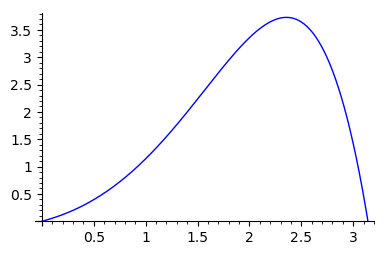

In [10]:
# Dibujamos la función
plot(f(x), x, a, b,figsize=4)

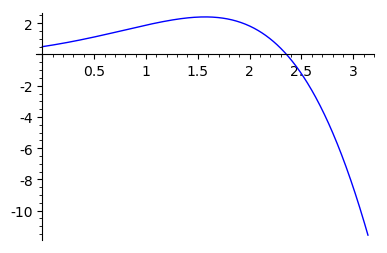

In [11]:
# Parece que solo hay un valor en el que se anula la derivada
# Lo comprobamos dibujando la derivada
derivada=diff(f(x), x)
plot(derivada, x, a, b,figsize=4)

In [12]:
# Efectivamente, solo hay un valor posible para c, que a ojo veo que está entre 2.3 y 2.4. 
# Lo obtengo con find_root (RECUERDA: "solve" equivale más o menos a "despeja", pero no siempre se puede despejar)
c=find_root(derivada,2.3,2.4)
c

2.356194490192345

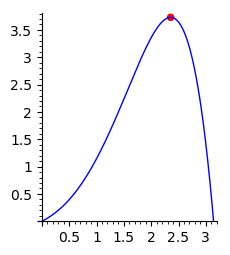

In [13]:
plot(f, 0, pi,aspect_ratio=1,figsize=4)+points([(c, f(c))], color='red', size=30)

**b)** Calcula **todos** los valores correctos (aproximados) para el $d$ del enunciado del Teorema Integral del Valor Medio aplicado a dicha $f$ en ese intervalo $[a,b]$. ¿Cuántos posibles valores de $d$ crees que existen?


*Sugerencia:* Como en el apartado a), te puede ayudar dibujar las gráficas de $f$ y de alguna función auxiliar.

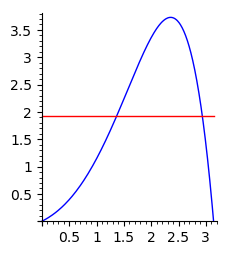

In [14]:
numero=integral(f(x), x, a, b)/(b-a)
plot(f(x), x, a, b,aspect_ratio=1,figsize=4)+plot(numero, x, a, b, color='red')

In [15]:
# Busco el primer punto entre 1 y 1.5
d1=find_root(f-numero,1,1.5)
d1

1.3669450347774785

In [16]:
# Busco el segundo punto entre 2.5 y 3.5
d2=find_root(f-numero,2.5,3.5)
d2

2.936280365810694

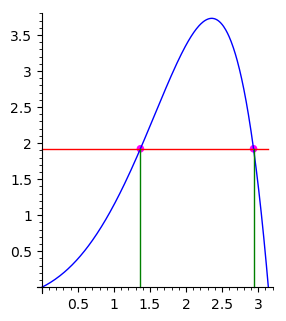

In [17]:
#Ilustro con un dibujo, concatenando diferentes imágenes
dibujo2b=plot(f,a, b,aspect_ratio=1,figsize=5)
dibujo2b+=plot(numero, a, b, color='red')
dibujo2b+=line([(d1,0),(d1,f(d1))],color='green')
dibujo2b+=line([(d2,0),(d2,f(d2))],color='green')
dibujo2b+=points([(d1, f(d1)),(d2, f(d2))],color='magenta',size=30)
show(dibujo2b)

In [18]:
# Comprobamos
N(f(d1)-numero),N(f(d2)-numero) # Estamos resolviendo de forma aproximada, así que no me saldrá exactamente 0

(2.22044604925031e-16, 2.88657986402541e-15)